In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict
from sklearn.preprocessing import StandardScaler

In [16]:
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')


In [17]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

if "sii" in num_cols:
    num_cols.remove("sii")

print("Number of numerical predictors:", len(num_cols))
print(num_cols)

Number of numerical predictors: 32
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time']


In [18]:
X_num = df[num_cols].copy()

print("Shape of X_num:", X_num.shape)
X_num.head()

Shape of X_num: (8460, 32)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
0,5.0,0.0,51,46.000000,50.8,26.000000,69,5,87,114,...,9.21377,1,24.434900,8.895360,38.9177,19.541300,2.12927,60,3,448
1,9.0,0.0,66,48.000000,46.0,22.000000,75,5,70,122,...,3.97085,1,21.035200,14.974000,39.4497,15.410700,2.01000,64,0,434
2,10.0,1.0,71,56.500000,75.6,26.003679,65,5,94,117,...,16.17460,2,30.424101,32.959842,56.9964,33.418724,2.17000,54,2,453
3,9.0,0.0,71,56.000000,81.6,26.000000,60,6,97,117,...,18.82430,2,30.404100,16.779000,58.9338,26.479800,2.45100,45,0,577
4,18.0,1.0,65,62.206792,77.0,26.000000,68,5,80,116,...,16.17460,2,28.855800,23.975607,56.9964,33.915114,1.04000,58,1,433


In [19]:
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_num)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=num_cols,
    index=df.index
)


## LMDD

In [20]:
from pyod.models.lmdd import LMDD

In [ ]:
clf_lmdd = LMDD(
    contamination=0.10,
    dis_measure="aad",
    n_iter=50,
    random_state=42
)

clf_lmdd.fit(X_scaled)

In [ ]:
lmdd_scores = clf_lmdd.decision_scores_

lmdd_scores[:10]

In [ ]:
lmdd_results = pd.DataFrame({
    "lmdd_score": lmdd_scores,
    "lmdd_outlier": lmdd_labels
}, index=df.index)

lmdd_results.head()

In [ ]:
lmdd_results["lmdd_outlier"].value_counts()
lmdd_results["lmdd_outlier"].value_counts(normalize=True) * 100

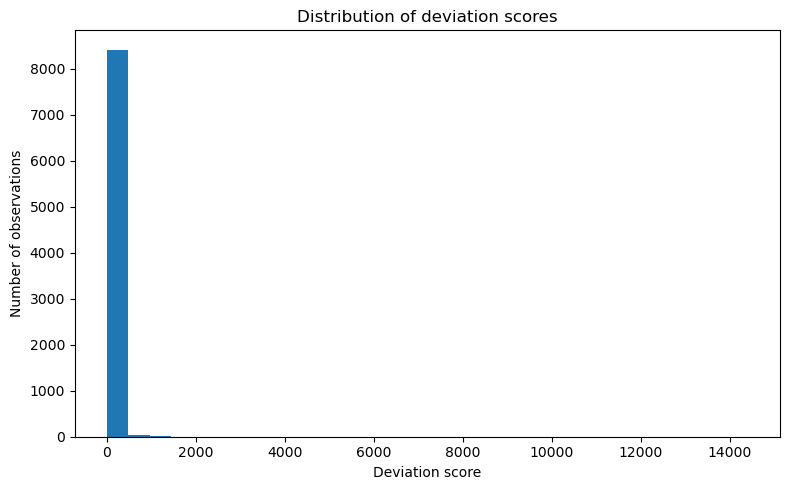

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(lmdd_results["lmdd_score"], bins=30)

plt.title("Distribution of LMDD anomaly scores")
plt.xlabel("LMDD score")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(clf_lmdd.decision_scores_, bins=20)

plt.axvline(
    np.min(clf_lmdd.decision_scores_[np.where(lmdd_labels == 1)]),
    color="black",
    linestyle="--",
    label="Outlier threshold"
)

plt.title("Distribution of LMDD anomaly scores with threshold")
plt.xlabel("LMDD score")
plt.ylabel("Number of observations")
plt.legend()
plt.tight_layout()
plt.show()

0    7614
1     846
Name: count, dtype: int64

In [ ]:
deviation_results = pd.DataFrame({
    "deviation_score": deviation_scores,
    "deviation_outlier": deviation_outlier
}, index=df.index)

deviation_results.sort_values("deviation_score", ascending=False).head(10)

,deviation_score,deviation_outlier
3205,14411.965918,1
6767,3140.022099,1
7646,2822.350986,1
4626,2358.218433,1
5448,2293.108568,1
7890,2240.613768,1
6273,1996.082512,1
4316,1890.064927,1
5046,1512.179820,1
5608,1492.691538,1


In [ ]:
top_deviation_indices = deviation_results.sort_values(
    "deviation_score",
    ascending=False
).head(10).index

pd.concat(
    [
        deviation_results.loc[top_deviation_indices],
        df.loc[top_deviation_indices, num_cols]
    ],
    axis=1
)

,deviation_score,deviation_outlier,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
3205,14411.965918,1,9.0,1.0,50,54.00,70.400000,37.499193,75,5,...,0.000000e+00,2,2457.910000,3108.170000,4683.710000,3607.690000,2.010000,51,0,420
6767,3140.022099,1,6.0,0.0,60,62.74,75.300000,27.750000,62,5,...,7.120719e+01,1,701.380965,1349.787669,51.402641,3020.346518,2.000000,68,0,396
7646,2822.350986,1,12.0,0.0,60,72.98,57.800000,27.427697,54,5,...,1.244883e+01,2,51.978012,3108.170000,121.986802,44.911752,1.000000,80,1,450
4626,2358.218433,1,16.0,0.0,72,74.12,268.568004,29.500000,78,4,...,0.000000e+00,2,41.686487,27.834827,83.788937,382.828957,1.657518,53,2,927
5448,2293.108568,1,10.0,0.0,72,59.97,114.700000,27.500000,54,5,...,1.776357e-15,2,578.868995,1115.317111,70.244823,39.629170,2.000000,56,1,293
7890,2240.613768,1,10.0,0.0,54,58.51,105.100000,27.750000,62,4,...,1.776357e-15,2,29.196229,34.194544,79.447272,32.530081,3.000000,94,0,288
6273,1996.082512,1,16.0,0.0,49,69.82,150.900000,35.500000,114,4,...,1.776357e-15,3,49.538173,34.239263,100.841409,58.605178,2.000929,60,2,478
4316,1890.064927,1,9.0,1.0,58,56.11,104.500000,33.185394,96,5,...,4.739136e+01,2,2117.039117,17.136938,67.479052,764.601458,2.000000,46,1,380
5046,1512.179820,1,11.0,0.0,53,65.93,168.200000,37.250000,72,4,...,0.000000e+00,2,165.041418,24.511055,4683.710000,39.584559,2.000000,70,1,478
5608,1492.691538,1,10.0,0.0,60,55.05,140.900000,31.830197,70,5,...,3.165788e+01,2,34.815523,127.660277,4683.710000,41.430665,3.000000,54,0,402


In [21]:
clf = LMDD()
clf.fit(X_scaled)

,contamination,0.1
,n_iter,50
,dis_measure,'aad'
,random_state,None


In [22]:
X_scaled_np = X_scaled.to_numpy()

clf.fit(X_scaled_np)

outliers = clf.predict(X_scaled_np)

np.unique(outliers, return_counts=True)

(array([0, 1]), array([7614,  846], dtype=int64))

In [23]:
from standardize_labels import standardize_labels 
# 1. import matrix
od_results = pd.read_csv('./Outliers/outliers_matrix.csv').set_index('row_id')

# 2. Unify labels (LMDD uses 1 for outliers, we want 1)
new_standard_labels = standardize_labels(outliers, method_type='pyod_or_manual')

# 3. Add the new column to the existing DataFrame
od_results['outlier_LMDD'] = new_standard_labels

# 4. Overwrite the master file with the added column
od_results.to_csv('./Outliers/outliers_matrix.csv', index_label='row_id')

In [ ]:
def sf(x, X):
    idx = list(X).index(x)
    X1 = np.array([x1 for i, x1 in enumerate(X) if i != idx])
    return np.abs(np.var(X) - np.var(X1))

In [ ]:
for i, x in enumerate(X_scaled_np[:, 0]):
    print(i, sf(x, X_scaled_np[:, 0]))

0 0.00013588192088753726
1 0.00010398465138772295
2 0.0001176834372806912
3 0.00010398465138772295
4 0.00043898341890846737
5 4.7736937737186125e-05
6 0.0001176834372806912
7 0.0001176834372806912
8 9.142977630993698e-05
9 0.0005918489188484477
10 0.0001128750803032208
11 0.0001128750803032208
12 4.7736937737186125e-05
13 8.95595804555338e-05
14 8.95595804555338e-05
15 2.106565099091462e-05
16 0.00013588192088753726
17 0.0001176834372806912
18 4.8154563513036486e-05
19 0.0001176834372806912
20 1.2592847851045086e-05
21 0.00018877384763904548
22 8.95595804555338e-05
23 4.7736937737186125e-05
24 9.142977630993698e-05
25 0.00010398465138772295
26 4.8154563513036486e-05
27 4.8154563513036486e-05
28 4.7736937737186125e-05
29 7.177872262431606e-05
30 9.142977630993698e-05
31 8.95595804555338e-05
32 0.00018877384763904548
33 2.106565099091462e-05
34 2.106565099091462e-05
35 9.142977630993698e-05
36 2.106565099091462e-05
37 0.0001176834372806912
38 4.8154563513036486e-05
39 0.00010398465138772

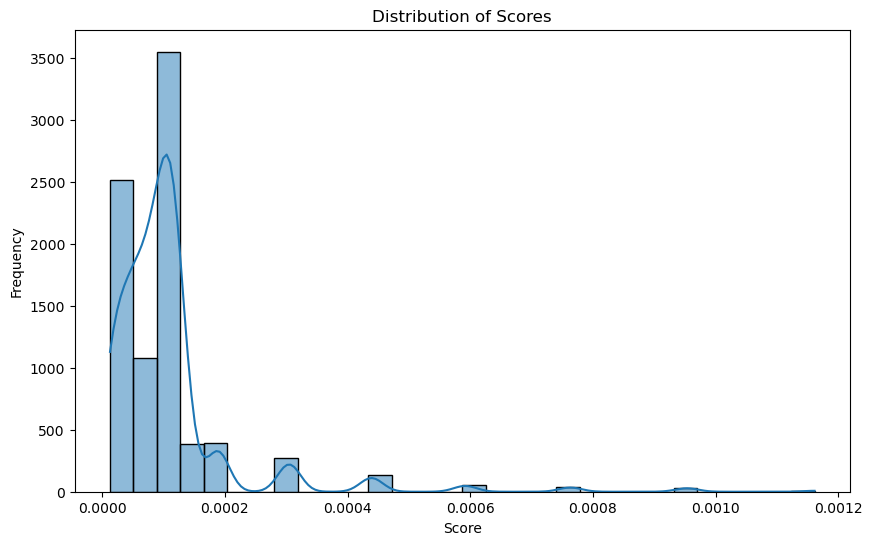

In [ ]:
# plotting only the highest scores
scores = [sf(x, X_scaled_np[:, 0]) for x in X_scaled_np[:, 0]]
plt.figure(figsize=(10, 6))
sns.histplot(scores, bins=30, kde=True)
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

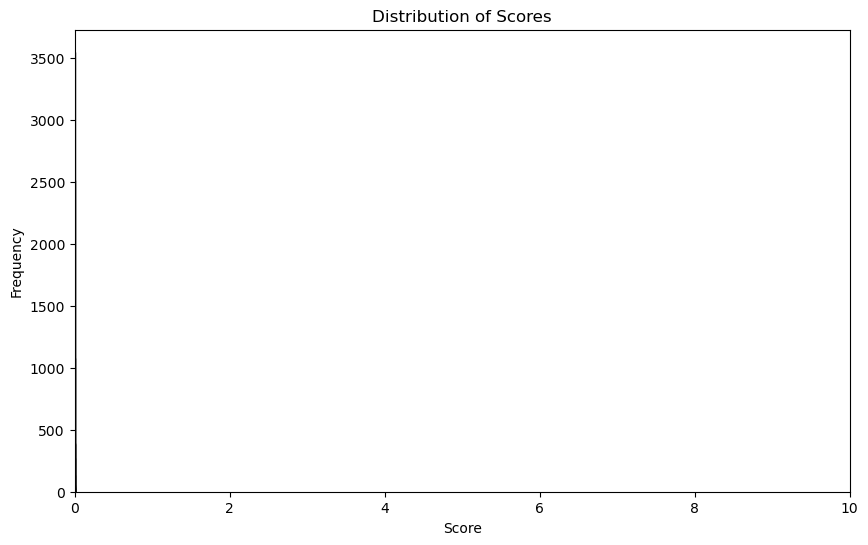

In [12]:
#plotting the highest scores
plt.figure(figsize=(10, 6))
sns.histplot(scores, bins=30, kde=True)
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.xlim(0, 10)  # Adjust the x-axis limits to focus on the highest scores
plt.show()